# Predict Students' Dropout and Academic Success
**CSAI 801 – Winter 2026 | Queen's University | Group 8**

Dataset: Realinho et al. (2021) — 4,424 students, 35 features, 3-class outcome

**Part 1 of 2 — Data Exploration & Preprocessing**

# 1. Setup & Imports

In [46]:
#!pip install imbalanced-learn xgboost lightgbm catboost shap -q

In [47]:
# Libraries
import os, random
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Suppress non-critical warnings
import warnings
warnings.filterwarnings('ignore')

# Statistics & ML utilities
from scipy.stats import spearmanr, chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

import joblib


In [48]:
# Fix the random seed so results are reproducible across runs
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

# Consistent color palette
PRIMARY   = '#006699'   # dark blue
SECONDARY = '#87CEFA'   # light blue
TERTIARY  = '#003d5c'   # navy

# Target classes
class_names = ['Dropout', 'Enrolled', 'Graduate']

# 2. Exploratory Data Analysis

In [49]:
# Load the dataset
df = pd.read_csv('dataset.csv')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

In [51]:
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,6.886980,1.727848,9.899186,0.890823,2.531420,1.254521,12.322107,16.455244,7.317812,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,5.298964,1.313793,4.331792,0.311897,3.963707,1.748447,9.026251,11.044800,3.997828,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,8.000000,1.000000,10.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,18.000000,9.000000,17.000000,1.000000,17.000000,21.000000,29.000000,34.000000,32.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [52]:
# Check missing values and duplicate rows
print('Missing values:', df.isnull().sum().sum())
print('Duplicates    :', df.duplicated().sum())

Missing values: 0
Duplicates    : 0


## **Comments**

**What we found in the initial data scan:**
- Dataset has **4,424 student records** across **35 columns** — a reasonably sized tabular dataset
- **No missing values** and **no duplicate rows** — means we can skip imputation and deduplication entirely
- All features are already numeric, so **no encoding is needed** for the input columns
- The only column that needs mapping is `Target`: `Dropout=0`, `Enrolled=1`, `Graduate=2`

## 2.1 Target Class Distribution

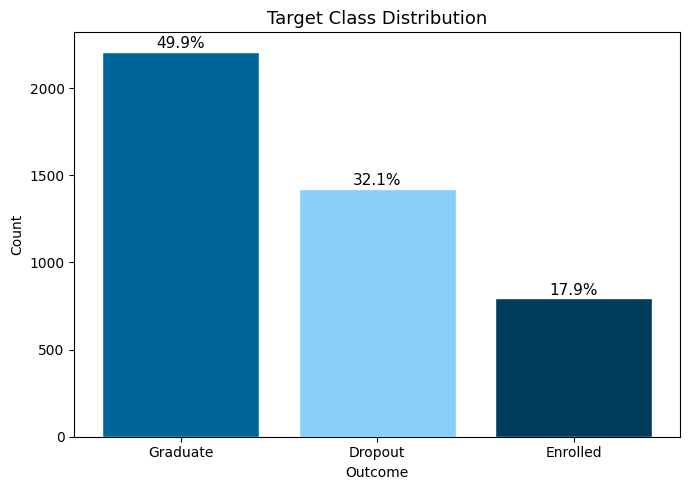

In [53]:
# Count how many students fall into each outcome class
counts      = df['Target'].value_counts()
percentages = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(7, 5))

# Draw bars with one color per class
bars = ax.bar(counts.index, counts.values,
               color=[PRIMARY, SECONDARY, TERTIARY], edgecolor='white')

# Annotate each bar with its percentage so we don't have to eyeball proportions
for bar, pct in zip(bars, percentages):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{pct:.1f}%', ha='center', fontsize=11)

ax.set_title('Target Class Distribution', fontsize=13)
ax.set_xlabel('Outcome')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## **Comments**

**Key takeaways from the class distribution:**
- Three clearly **imbalanced** classes: Graduate ~50%, Dropout ~32%, Enrolled ~18%
- A naive model that always predicts *Graduate* would hit ~50% accuracy while completely **ignoring Dropout and Enrolled** — not actually useful
- This is exactly why we use **F1-macro** as our evaluation metric — it penalizes poor performance on *any* class equally
- The Dummy (Most Frequent) baseline scores only **0.1641 F1-macro** despite ~32% accuracy, which makes the imbalance problem concrete and measurable

## 2.2 Academic Performance by Outcome

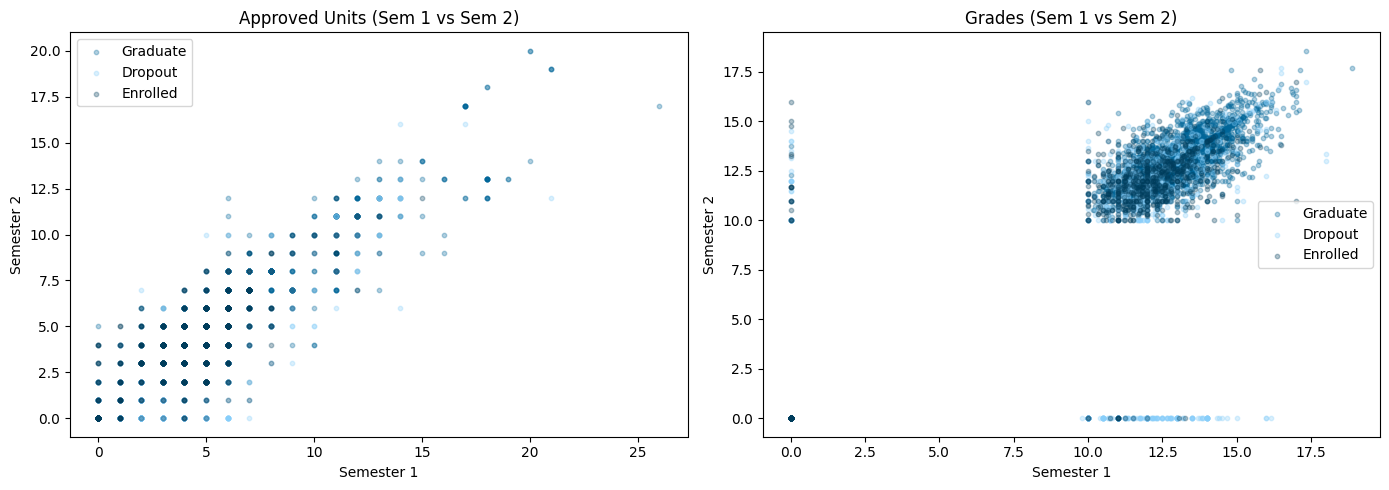

In [54]:
color_map = {'Graduate': PRIMARY, 'Dropout': SECONDARY, 'Enrolled': TERTIARY}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot each outcome group as a separate layer so the overlap pattern is visible
for outcome, color in color_map.items():
    s = df[df['Target'] == outcome]

    # Left plot: how many units did students get approved across both semesters?
    axes[0].scatter(s['Curricular units 1st sem (approved)'],
                    s['Curricular units 2nd sem (approved)'],
                    alpha=0.3, label=outcome, color=color, s=10)

    # Right plot: what were their grades across both semesters?
    axes[1].scatter(s['Curricular units 1st sem (grade)'],
                    s['Curricular units 2nd sem (grade)'],
                    alpha=0.3, label=outcome, color=color, s=10)

for ax, title in zip(axes, ['Approved Units (Sem 1 vs Sem 2)', 'Grades (Sem 1 vs Sem 2)']):
    ax.set_title(title); ax.set_xlabel('Semester 1')
    ax.set_ylabel('Semester 2'); ax.legend()

plt.tight_layout(); plt.show()

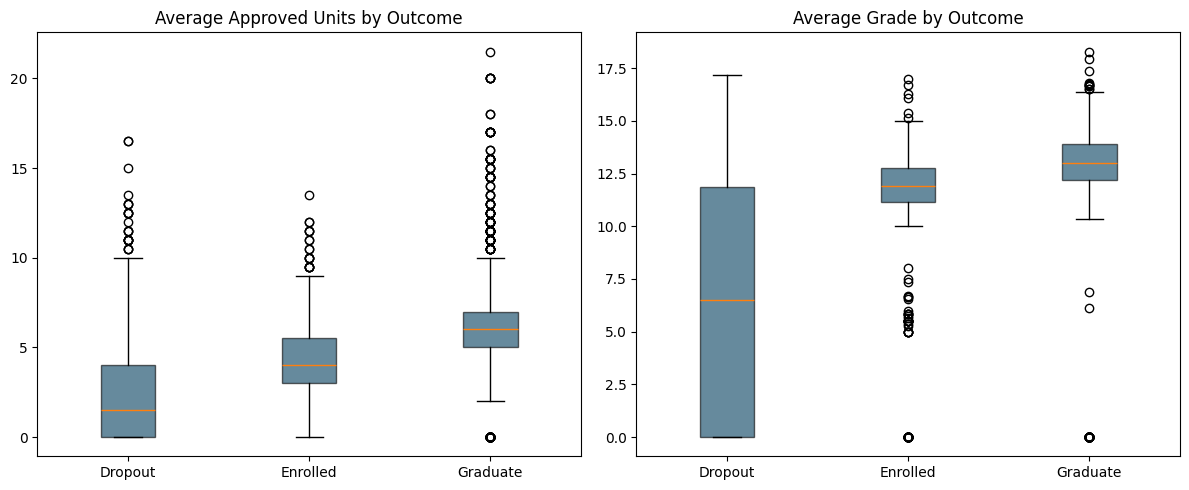

In [55]:
# Create temporary average columns just for the boxplot comparison
df['avg_approved_tmp'] = (df['Curricular units 1st sem (approved)'] +
                           df['Curricular units 2nd sem (approved)']) / 2
df['avg_grade_tmp']    = (df['Curricular units 1st sem (grade)'] +
                           df['Curricular units 2nd sem (grade)']) / 2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(axes,
        ['avg_approved_tmp', 'avg_grade_tmp'],
        ['Average Approved Units by Outcome', 'Average Grade by Outcome']):

    # Group values by outcome class for side-by-side boxplot comparison
    data = [df[df['Target'] == o][col].values for o in ['Dropout', 'Enrolled', 'Graduate']]
    ax.boxplot(data, patch_artist=True, boxprops=dict(facecolor=TERTIARY, alpha=0.6))
    ax.set_xticklabels(['Dropout', 'Enrolled', 'Graduate'])
    ax.set_title(title)

plt.tight_layout(); plt.show()

df.drop(columns=['avg_approved_tmp', 'avg_grade_tmp'], inplace=True)

## **Comments**

**What the academic performance plots tell us:**
- **Approved units are the strongest visual separator** — Dropouts cluster near zero in both semesters, while Graduates sit consistently high
- Enrolled students fall **in between**, overlapping with both extremes — this is why distinguishing Enrolled is harder
- That overlap is a genuine feature ambiguity, not a modeling failure — it explains why **Enrolled F1 (0.54) sits well below** **Dropout (0.78) and Graduate (0.87)** across every model we tested
- The grade distributions tell a similar story but with less separation, confirming that *completion* matters more than *score*

## 2.3 Financial Factors vs. Outcome

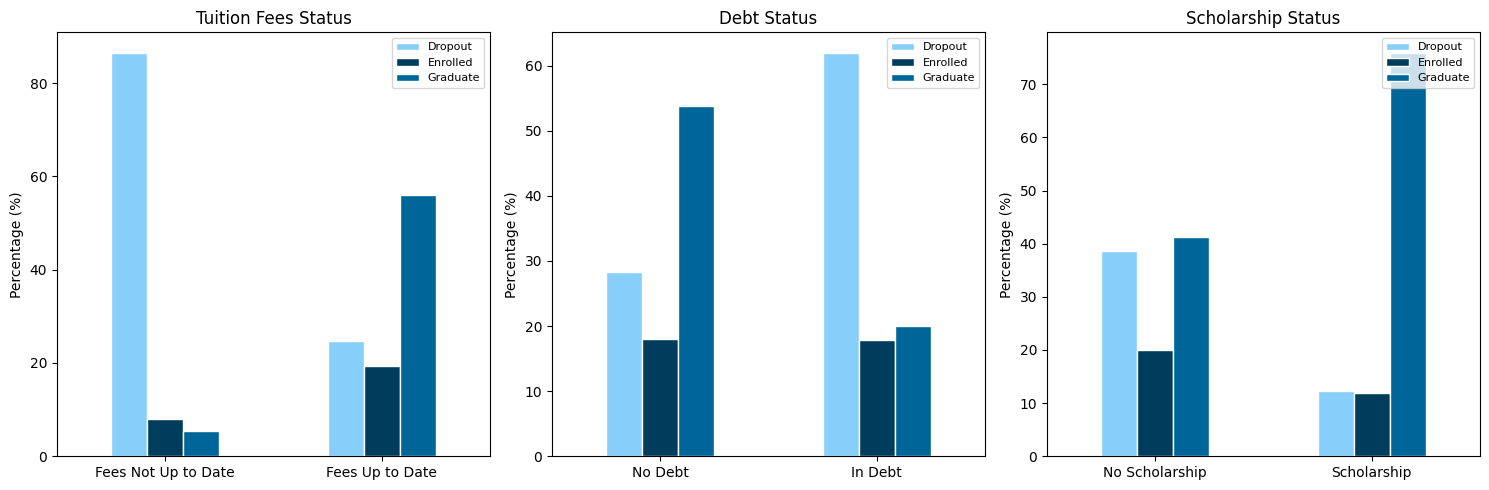

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Compare outcome distributions across three binary financial features
for ax, col, labels, title in zip(
        axes,
        ['Tuition fees up to date', 'Debtor', 'Scholarship holder'],
        [['Fees Not Up to Date', 'Fees Up to Date'],
         ['No Debt', 'In Debt'], ['No Scholarship', 'Scholarship']],
        ['Tuition Fees Status', 'Debt Status', 'Scholarship Status']):


    grouped = df.groupby([col])['Target'].value_counts(normalize=True).unstack() * 100
    grouped.index = labels
    grouped.plot(kind='bar', ax=ax, color=[SECONDARY, TERTIARY, PRIMARY], edgecolor='white')
    ax.set_title(title); ax.set_ylabel('Percentage (%)')
    ax.set_xlabel(''); ax.tick_params(axis='x', rotation=0)
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout(); plt.show()

## **Comments**

**Financial factors and their dropout signal:**
- **Tuition fees up to date** is the clearest binary split in the entire dataset — students with overdue fees drop out at over **85%**
- This explains why it ranks **5th in SHAP** (mean |SHAP| = 0.0309) despite being a simple binary flag — it has outsized influence on individual predictions
- **Scholarship holders** graduate at the highest rate — likely reflects both financial relief and academic selection
- **Debtors** trend toward dropout but less strongly than the tuition flag — debt alone isn't the deciding factor
- Takeaway: financial stability and academic performance are two largely **independent axes of risk**, and both survive feature selection


## 2.4 Demographic Factors vs. Outcome

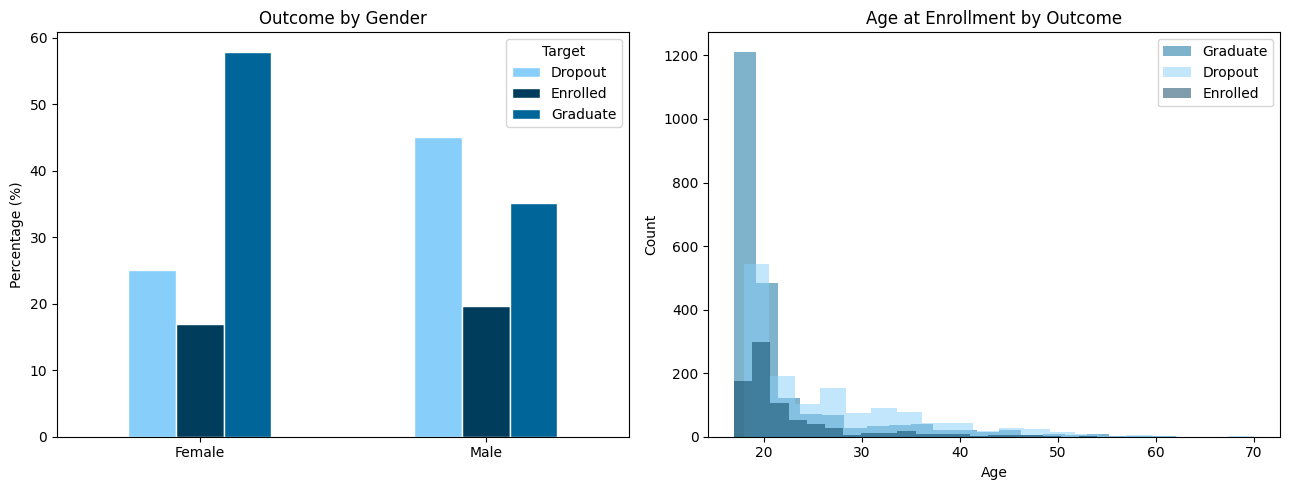

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: stacked bar of outcomes broken down by gender
gender_outcome = df.groupby('Gender')['Target'].value_counts(normalize=True).unstack() * 100
gender_outcome.index = ['Female', 'Male']
gender_outcome.plot(kind='bar', ax=axes[0],
                    color=[SECONDARY, TERTIARY, PRIMARY], edgecolor='white')
axes[0].set_title('Outcome by Gender')
axes[0].set_xlabel(''); axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=0)

# Right: overlapping histograms of enrollment age split by outcome
for outcome, color in color_map.items():
    axes[1].hist(df[df['Target'] == outcome]['Age at enrollment'],
                 bins=20, alpha=0.5, label=outcome, color=color)
axes[1].set_title('Age at Enrollment by Outcome')
axes[1].set_xlabel('Age'); axes[1].set_ylabel('Count'); axes[1].legend()

plt.tight_layout(); plt.show()

## **Comments**

**What demographics add to the picture:**
- **Male students drop out at a noticeably higher rate** than female students — gender is a real signal, not just noise
- Students enrolling **after age 25** show elevated dropout rates — competing work or family commitments likely explain this pattern
- Both features survived statistical selection:
  - **Gender** passed Chi-Square + Cramér's V (V ≥ 0.10 threshold)
  - **Age at enrollment** has Spearman r = **−0.275** — a meaningful negative correlation with graduation
- These demographic signals are especially useful for the **Enrolled class**, where academic features alone are ambiguous

## 2.5 Correlation Heatmap

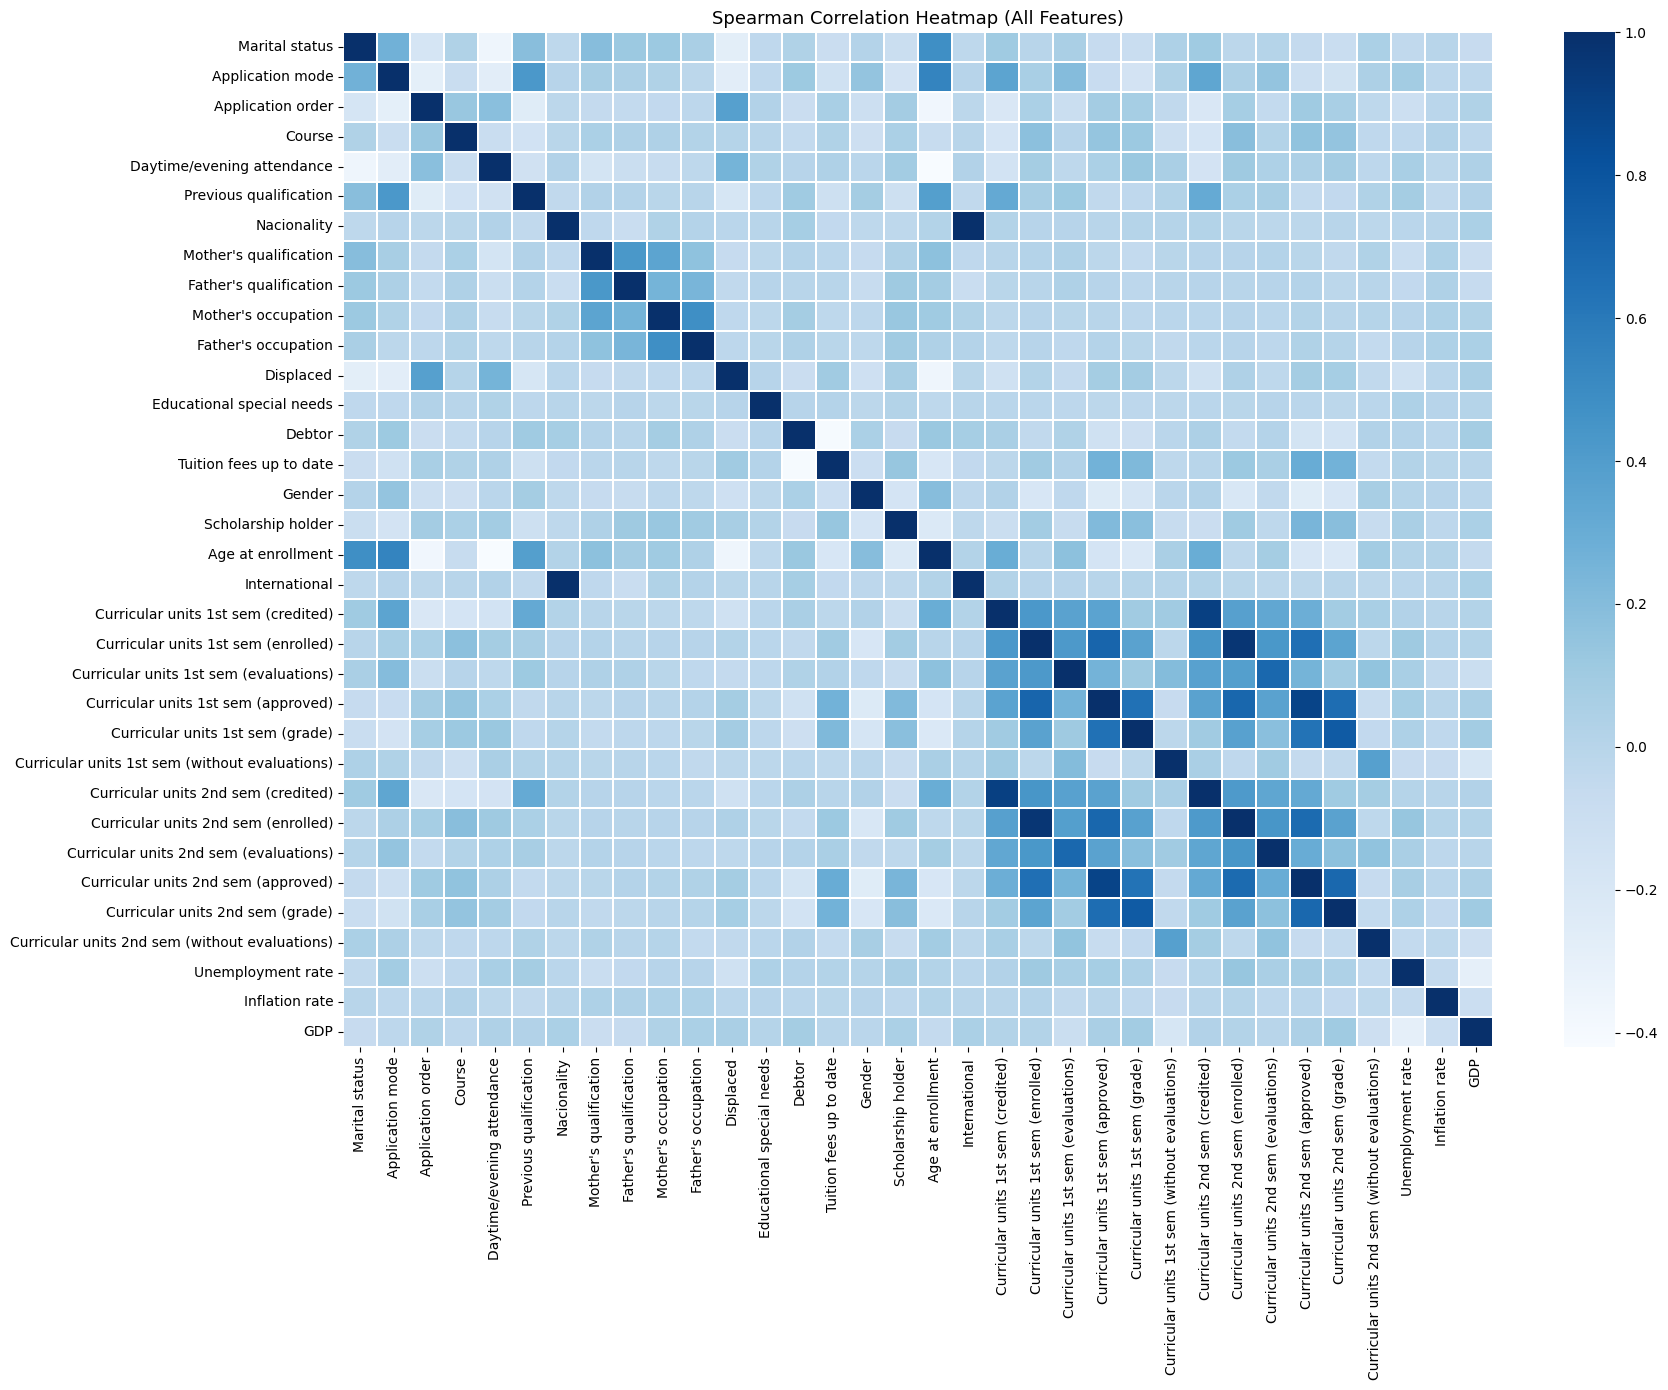

In [58]:
# Encode the target as a number to be included in the Spearman correlation matrix
label_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['Target_enc'] = df['Target'].map(label_map)

# Only include numeric columns, and exclude the encoded target from the feature matrix
num_cols = df.select_dtypes(include='number').columns.drop('Target_enc').tolist()

fig, ax = plt.subplots(figsize=(18, 14))

# Spearman rank correlation
sns.heatmap(df[num_cols].corr(method='spearman'), cmap='Blues',
            annot=False, linewidths=0.3, ax=ax)
ax.set_title('Spearman Correlation Heatmap (All Features)', fontsize=13)
plt.tight_layout(); plt.show()

## **Comments**

**What the heatmap reveals about feature redundancy:**
- Two **high-multicollinearity blocks** are clearly visible in the heatmap
- The **12 raw semester columns** (approved, enrolled, grade, etc.) move nearly in lockstep — keeping all 12 would inflate model variance without adding new information
- The **macroeconomic block** (GDP, Inflation, Unemployment) also correlates internally
- Our fix: collapse the 6 sem1/sem2 pairs into **averages** (see Section 3.2), while separately preserving 2nd-semester raw values that Realinho et al. identify as the strongest individual predictors
- This reduces noise and keeps the feature space clean before selection

# 3. Data Preprocessing

## 3.1 Remove Outliers

In [59]:
# Find students labeled as Graduate who have zero approved units in both semesters
outliers = df[
    (df['Curricular units 1st sem (approved)'] == 0) &
    (df['Curricular units 2nd sem (approved)'] == 0) &
    (df['Target'] == 'Graduate')
].index

print(f'Outlier rows removed: {len(outliers)}')
df = df.drop(index=outliers).reset_index(drop=True)
print(f'Dataset size after removal: {df.shape[0]} rows')

Outlier rows removed: 75
Dataset size after removal: 4349 rows


## **Comments**

**Why these 75 rows are dropped:**
- We found **75 students** labeled *Graduate* but with **zero approved units in both semesters** — that's a direct contradiction
- Graduation requires completing coursework, so these records are almost certainly **data entry errors**, not real edge cases
- Keeping them would teach the model a false pattern: that a student with no academic activity can still graduate
- Removing them shrinks the dataset slightly (**4,424 → 4,349**) but makes the label semantics trustworthy

## 3.2 Feature Engineering

In [60]:
# sem2_approved_raw is kept separately because Realinho et al. flag it as the top dropout predictor
df['sem2_approved_raw'] = df['Curricular units 2nd sem (approved)']
df['sem2_grade_raw']    = df['Curricular units 2nd sem (grade)']
df['sem1_grade_raw']    = df['Curricular units 1st sem (grade)']

# (sem1 column, sem2 column, new average column name)
sem_pairs = [
    ('Curricular units 1st sem (credited)',             'Curricular units 2nd sem (credited)',             'avg_credited'),
    ('Curricular units 1st sem (enrolled)',             'Curricular units 2nd sem (enrolled)',             'avg_enrolled'),
    ('Curricular units 1st sem (evaluations)',          'Curricular units 2nd sem (evaluations)',          'avg_evaluations'),
    ('Curricular units 1st sem (approved)',             'Curricular units 2nd sem (approved)',             'avg_approved'),
    ('Curricular units 1st sem (grade)',                'Curricular units 2nd sem (grade)',                'avg_grade'),
    ('Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (without evaluations)', 'avg_without_eval'),
]

# Average each sem1/sem2 pair into a single column and drop the originals
for c1, c2, name in sem_pairs:
    df[name] = (df[c1] + df[c2]) / 2
    df.drop(columns=[c1, c2], inplace=True)

print(f'Features after averaging: {df.shape[1]} columns')

Features after averaging: 33 columns


In [61]:
# grade_trend: did the student improve or decline between sem1 and sem2?
df['grade_trend']   = df['sem2_grade_raw'] - df['sem1_grade_raw']

# approval_rate: what fraction of enrolled units were actually approved?
df['approval_rate'] = (df['avg_approved'] / (df['avg_enrolled'] + 1e-5)).clip(0, 1)

# failed_units: how many enrolled units were NOT approved on average?
df['failed_units']  = df['avg_enrolled'] - df['avg_approved']

engineered = ['sem2_approved_raw', 'grade_trend', 'approval_rate', 'failed_units']
print('Engineered features:', engineered)

Engineered features: ['sem2_approved_raw', 'grade_trend', 'approval_rate', 'failed_units']


## **Comments**

**Four engineered features:**

- **`approval_rate`** *(Spearman r = 0.750, strongest predictor)*. Measures academic efficiency, not raw volume. A student enrolling in many units but approving few looks worse than someone with fewer units all approved

- **`sem2_approved_raw`** *(r = 0.694)* — 2nd-semester approved units kept as-is. Realinho et al. identify this as the single strongest dropout predictor. Averaging it with sem1 would dilute the signal when a student crashes in the second semester

- **`failed_units`** *(r = −0.684)* — enrolled minus approved. Captures the effort-vs-outcome gap independently of the raw approval count — a student who fails many units is flagged even if their average looks okay

- **`grade_trend`** *(r = 0.126)* — sem2 grade minus sem1 grade. Direction matters even when both semesters have similar averages — a student improving over time is different from one declining

## 3.3 Train / Validation / Test Split

In [62]:
X_raw = df.drop(columns=['Target', 'Target_enc'])
y = df['Target_enc']

# First split off 20% as a held-out test set
X_trainval_raw, X_test_raw, y_trainval, y_test = train_test_split(
    X_raw, y, test_size=0.20, stratify=y, random_state=SEED
)

# SecondsSplit the remaining 80% into train (85%) and validation (15%)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_trainval_raw, y_trainval, test_size=0.15, stratify=y_trainval, random_state=SEED
)

print(f'Train : {X_train_raw.shape} | Val: {X_val_raw.shape} | Test: {X_test_raw.shape}')
print(f'Train class dist: {pd.Series(y_train).value_counts().sort_index().to_dict()}')
print(f'Val   class dist: {pd.Series(y_val).value_counts().sort_index().to_dict()}')
print(f'Test  class dist: {pd.Series(y_test).value_counts().sort_index().to_dict()}')

Train : (2957, 34) | Val: (522, 34) | Test: (870, 34)
Train class dist: {0: 966, 1: 540, 2: 1451}
Val   class dist: {0: 171, 1: 95, 2: 256}
Test  class dist: {0: 284, 1: 159, 2: 427}


## **Comments**

- Three-way split: **2,957 train (68%)**, **522 val (12%)**, **870 test (20%)**
- `stratify=y` preserves the class imbalance across all three sets — Train: Dropout 966, Enrolled 540, Graduate 1,451 mirrors the full dataset ratio
- **Train set** — all model fitting and feature selection happens here only
- **Validation set** — reserved for threshold calibration
- **Test set** — touched exactly once, at the final evaluation step in Notebook 2


## 3.4 Feature Selection — Chi-Square + Cramér's V + Spearman

In [63]:
def cramers_v(x, y):
    ct   = pd.crosstab(x, y)               
    chi2 = chi2_contingency(ct)[0]         
    n    = ct.sum().sum()                  
    r, k = ct.shape                        
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))  


# Attach encoded target to the training slice so we can compute associations
train_sel = X_train_raw.copy()
train_sel['Target_enc'] = y_train.values

# Features treated as categorical (binary flags, ordinal codes, nominal identifiers)
cat_cols = [
    'Marital status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
    "Mother's qualification", "Father's qualification", "Mother's occupation",
    "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International'
]

# Run Chi-Square + Cramér's V for every categorical feature
chi2_results = []
for col in cat_cols:
    ct      = pd.crosstab(train_sel[col], train_sel['Target_enc'])
    chi2, p = chi2_contingency(ct)[:2]     # chi2 statistic and p-value
    v        = cramers_v(train_sel[col], train_sel['Target_enc'])
    chi2_results.append({'Feature': col, 'chi2': round(chi2,2),
                          'p_value': round(p,5), 'cramers_v': round(v,3)})

chi2_df = pd.DataFrame(chi2_results).sort_values('cramers_v', ascending=False)

# Keep features that are both statistically significant AND have a meaningful effect size
sig_cat  = chi2_df[(chi2_df['p_value'] < 0.05) & (chi2_df['cramers_v'] >= 0.10)]['Feature'].tolist()

print(f'Significant categorical features ({len(sig_cat)}):', sig_cat)
print(f'Dropped:', [c for c in cat_cols if c not in sig_cat])

Significant categorical features (11): ['Tuition fees up to date', 'Scholarship holder', 'Course', 'Debtor', 'Gender', 'Application mode', "Mother's occupation", "Father's occupation", "Father's qualification", "Mother's qualification", 'Previous qualification']
Dropped: ['Marital status', 'Application order', 'Daytime/evening attendance', 'Nacionality', 'Displaced', 'Educational special needs', 'International']


In [64]:
# Identify numerical columns
new_num_cols = [
    c for c in train_sel.select_dtypes(include='number').columns
    if c not in ['Target_enc'] + cat_cols
]

# Compute Spearman rank correlation between each numerical feature and the encoded target
spearman_results = []
for col in new_num_cols:
    corr, p = spearmanr(train_sel[col], train_sel['Target_enc'])
    spearman_results.append({'Feature': col, 'Spearman_r': round(corr,3), 'p_value': round(p,5)})

spearman_df = pd.DataFrame(spearman_results).sort_values('Spearman_r', key=abs, ascending=False)

# Keep features that are statistically significant AND have at least a weak correlation (|r| ≥ 0.05)
sig_num     = spearman_df[
    (spearman_df['p_value'] < 0.05) & (spearman_df['Spearman_r'].abs() >= 0.05)
]['Feature'].tolist()

print(f'Significant numerical features ({len(sig_num)}):')
print(spearman_df[spearman_df['Feature'].isin(sig_num)].to_string(index=False))

Significant numerical features (11):
          Feature  Spearman_r  p_value
    approval_rate       0.750      0.0
sem2_approved_raw       0.694      0.0
     failed_units      -0.684      0.0
     avg_approved       0.681      0.0
        avg_grade       0.618      0.0
   sem2_grade_raw       0.601      0.0
   sem1_grade_raw       0.541      0.0
Age at enrollment      -0.275      0.0
     avg_enrolled       0.263      0.0
      grade_trend       0.126      0.0
 avg_without_eval      -0.109      0.0


Total selected features: 22


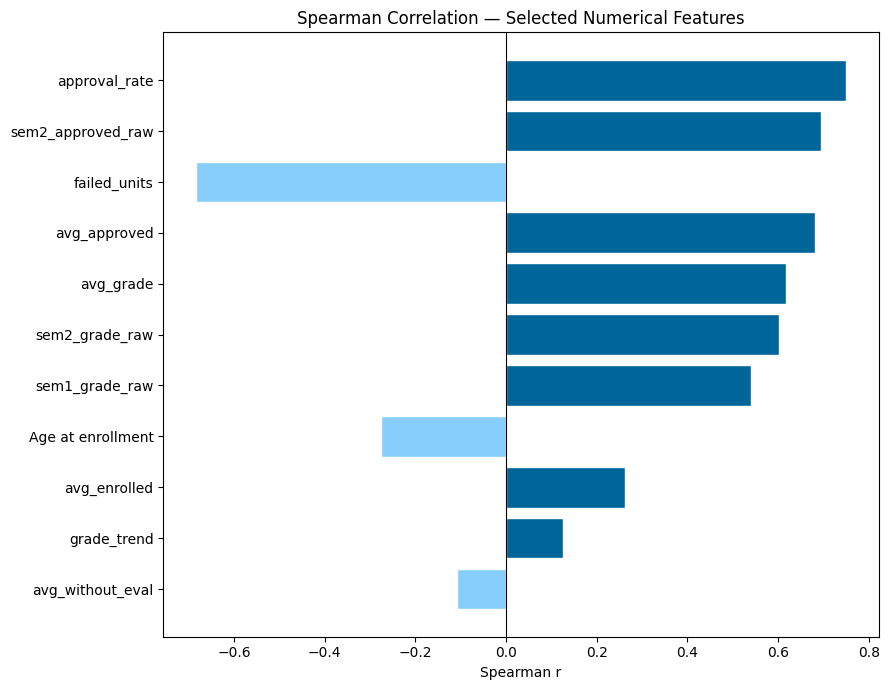

In [65]:
# Combine the passing categorical and numerical features into the final feature list
selected_features = sig_cat + sig_num
print(f'Total selected features: {len(selected_features)}')

# Sort by absolute correlation for the horizontal bar chart
plot_df = spearman_df[spearman_df['Feature'].isin(sig_num)].sort_values('Spearman_r', key=abs)

# Color bars by direction: positive correlations (→ Graduate) vs negative (→ Dropout)
colors  = [PRIMARY if r > 0 else SECONDARY for r in plot_df['Spearman_r']]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(plot_df['Feature'], plot_df['Spearman_r'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Spearman Correlation — Selected Numerical Features', fontsize=12)
ax.set_xlabel('Spearman r')
plt.tight_layout(); plt.show()

# Slice all three dataset splits down to selected features only
X_train_sel = X_train_raw[selected_features]
X_val_sel   = X_val_raw[selected_features]
X_test_sel  = X_test_raw[selected_features]

## **Comments**

**Feature selection approach and what got dropped:**
- **Chi-Square** tests whether a categorical feature's distribution shifts significantly across the three outcome classes
- **Cramér's V** adds effect size — on 4,349 rows almost anything reaches p < 0.05, so we require **V ≥ 0.10** as a minimum practical threshold
- **7 categorical features were dropped**: Marital status, Application order, Daytime/evening attendance, Nacionality, Displaced, Educational special needs, and International — all failed the effect size requirement
- For numerical features, **Spearman** captures monotonic relationships without assuming linearity — `approval_rate` leads at r = 0.750, followed by `sem2_approved_raw` (0.694) and `failed_units` (−0.684)
- Final count: **11 categorical + 11 numerical = 22 selected features**, all evaluated on training data only to avoid leakage


## 3.5 Feature Scaling & SMOTE

In [ ]:
# Fit the scaler on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_val_scaled   = scaler.transform(X_val_sel)
X_test_scaled  = scaler.transform(X_test_sel)

# k_neighbors=5 means each new synthetic point is interpolated between a real sample and 5 of its neighbors

sm = SMOTE(random_state=SEED, k_neighbors=5)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print(f'Before SMOTE: {dict(pd.Series(y_train).value_counts().sort_index())}')
print(f'After  SMOTE: {dict(pd.Series(y_train_res).value_counts().sort_index())}')

Before SMOTE: {0: np.int64(966), 1: np.int64(540), 2: np.int64(1451)}
After  SMOTE: {0: np.int64(1451), 1: np.int64(1451), 2: np.int64(1451)}


## **Comments**

**Scaling and balancing:**
- **Before SMOTE**: Dropout 966, Enrolled 540, Graduate 1,451 — still imbalanced
- **After SMOTE**: all three classes balanced at **1,451** — the model now sees equal representation
- The scaler is fit on training data only — fitting on the full dataset would leak test distribution into training
- SMOTE generates **synthetic Enrolled examples** in feature space, which reshapes decision boundaries in a way that `class_weight='balanced'` alone cannot replicate
- The SMOTE-balanced set is used for **baseline model training** in Notebook 2
- During hyperparameter tuning, SMOTE runs fresh **inside each CV fold** via ImbPipeline — the validation fold never sees synthetic points during scoring, which is why tuned CV scores (0.73) closely match test scores (0.74), unlike the baseline CV scores(0.84) explained in Section 4.

## 3.6 Save Preprocessed Data

Save everything Notebook 2 needs so it can run independently.

In [ ]:
os.makedirs('preprocessed', exist_ok=True)

# Save each artifact with a descriptive name so Notebook 2 can load them without re-running this notebook

joblib.dump(X_train_scaled,    'preprocessed/X_train_scaled.pkl')   
joblib.dump(X_val_scaled,      'preprocessed/X_val_scaled.pkl')    
joblib.dump(X_test_scaled,     'preprocessed/X_test_scaled.pkl')    
joblib.dump(X_train_res,       'preprocessed/X_train_res.pkl')     
joblib.dump(y_train,           'preprocessed/y_train.pkl')          
joblib.dump(y_train_res,       'preprocessed/y_train_res.pkl')      
joblib.dump(y_val,             'preprocessed/y_val.pkl')            
joblib.dump(y_test,            'preprocessed/y_test.pkl')           
joblib.dump(X_train_sel,       'preprocessed/X_train_sel.pkl')      
joblib.dump(selected_features, 'preprocessed/selected_features.pkl') 
joblib.dump(scaler,            'preprocessed/scaler.pkl')           

print('Preprocessed data saved to preprocessed/')

Preprocessed data saved to preprocessed/


---
# **4. Notebook Summary**

**What we did in this notebook:**

- **Loaded and inspected** the dataset — 4,424 students, 35 features, no missing values or duplicates, all numeric except the `Target` label

- **Explored the data visually** across four angles:
  - Class distribution → confirmed severe imbalance (Graduate ~50%, Enrolled ~18%), justifying F1-macro as our metric
  - Academic performance → approved units are the strongest visual separator between classes
  - Financial factors → tuition fees up to date is the sharpest binary dropout predictor in the dataset
  - Demographic factors → older enrollment age and male gender are both meaningful dropout signals

- **Removed 75 logical outliers** — students labeled Graduate with zero approved units in both semesters

- **Engineered 4 new features** on top of averaged semester pairs:
  - `approval_rate` (r = 0.750) — the top predictor overall
  - `sem2_approved_raw` (r = 0.694) — 2nd-semester signal preserved separately
  - `failed_units` (r = −0.684) — effort-vs-outcome gap
  - `grade_trend` (r = 0.126) — direction of change between semesters

- **Split the data** into train (68%), validation (12%), and test (20%) with stratification to preserve class ratios

- **Selected 22 features** (11 categorical, 11 numerical) using Chi-Square + Cramér's V for categorical and Spearman correlation for numerical — all evaluated on training data only

- **Scaled and balanced** the training set: StandardScaler for normalization, SMOTE to balance classes from {966, 540, 1451} to {1451, 1451, 1451}

- **Saved all outputs** to `preprocessed/` so Notebook 2 can load them and go straight to modeling

 **Up next → Notebook 2**: Baseline models, hyperparameter tuning, SHAP analysis, threshold calibration, and final test evaluation